# 05 - TF-IDF + Random Forest

Sugerido explicitamente no enunciado do desafio. Em texto esparso de alta dimensao, a Random Forest tende a gerar artefato grande e inferencia mais lenta que um modelo linear - o que a comparacao vai confirmar ou refutar com numero medido.

**Entrada:** `data/processed/{train,val,test}.parquet`
**Saidas:** `models/tfidf_random_forest/model.pkl`, `metrics.json`, `search_log.csv`

> Este notebook tem a **mesma estrutura** dos demais notebooks de modelo. So muda o
> estimador. Isso e proposital: mantem a comparacao justa e o codigo previsivel.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import ensure_dirs, load_config, set_seed

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

SEED = set_seed()
CONFIG = load_config()
ensure_dirs()
print(f"seed={SEED} | classes={CONFIG['classes']}")

seed=42 | classes=['normal', 'atencao', 'urgente']


## 1. Busca de hiperparametros

A selecao acontece na **validacao**. O split de teste nao e tocado aqui.

In [2]:
from src.models.pipelines import param_grid

CANDIDATO = "tfidf_random_forest"
grade = param_grid(CANDIDATO)
print(f"Combinacoes a avaliar: {len(grade)}")
for params in grade:
    print(" ", params)

Combinacoes a avaliar: 8
  {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
  {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'class_weight': 'balanced'}
  {'n_estimators': 200, 'max_depth': 40, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
  {'n_estimators': 200, 'max_depth': 40, 'min_samples_leaf': 2, 'class_weight': 'balanced'}
  {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
  {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 2, 'class_weight': 'balanced'}
  {'n_estimators': 400, 'max_depth': 40, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
  {'n_estimators': 400, 'max_depth': 40, 'min_samples_leaf': 2, 'class_weight': 'balanced'}


## 2. Treino, avaliacao e latencia

`run_candidate` executa a busca, treina o modelo final, avalia em validacao e teste, mede latencia pelo protocolo unico e persiste os artefatos.

In [3]:
from src.models.experiment import run_candidate

resultado = run_candidate(CANDIDATO)
print("Melhores parametros:", resultado["best_params"])

Melhores parametros: {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 2, 'class_weight': 'balanced'}


### Log da busca

In [4]:
display(resultado["search_log"].head(10))

,params,f1_macro,f1_weighted,accuracy,recall_normal,precision_normal,recall_atencao,precision_atencao,recall_urgente,precision_urgente
0,"{""n_estimators"": 400, ""max_depth"": null, ""min_...",0.728696,0.720440,0.722090,0.658046,0.707883,0.713821,0.754296,0.855228,0.701099
1,"{""n_estimators"": 400, ""max_depth"": null, ""min_...",0.727612,0.719814,0.721496,0.649425,0.710692,0.728455,0.749164,0.844504,0.700000
2,"{""n_estimators"": 200, ""max_depth"": null, ""min_...",0.723652,0.715762,0.717340,0.649425,0.704050,0.720325,0.745791,0.839142,0.698661
3,"{""n_estimators"": 200, ""max_depth"": null, ""min_...",0.719801,0.711652,0.713183,0.652299,0.695253,0.702439,0.750000,0.844504,0.692308
4,"{""n_estimators"": 400, ""max_depth"": 40, ""min_sa...",0.713205,0.704741,0.706057,0.668103,0.678832,0.668293,0.751371,0.839142,0.692478
5,"{""n_estimators"": 400, ""max_depth"": 40, ""min_sa...",0.710376,0.701786,0.703088,0.670977,0.674855,0.660163,0.746324,0.833780,0.694196
6,"{""n_estimators"": 200, ""max_depth"": 40, ""min_sa...",0.707267,0.698181,0.699525,0.658046,0.670571,0.666667,0.740072,0.831099,0.693512
7,"{""n_estimators"": 200, ""max_depth"": 40, ""min_sa...",0.701516,0.692120,0.693587,0.647989,0.665192,0.663415,0.732496,0.828418,0.688196


## 3. Metricas

In [5]:
comparativo = pd.DataFrame({
    "validacao": resultado["val_metrics"],
    "teste": resultado["test_metrics"],
}).round(4)
display(comparativo)

,validacao,teste
f1_macro,0.7287,0.7273
f1_weighted,0.7204,0.7220
accuracy,0.7221,0.7228
recall_normal,0.6580,0.6743
precision_normal,0.7079,0.7121
recall_atencao,0.7138,0.7062
precision_atencao,0.7543,0.7699
recall_urgente,0.8552,0.8414
precision_urgente,0.7011,0.6804


> Uma queda grande de validacao para teste indica overfitting na busca de hiperparametros.

In [6]:
from src.data.loader import load_split
from src.evaluation.metrics import confusion, report

teste = load_split("test")
print(report(teste["urgencia"], resultado["test_pred"]))

              precision    recall  f1-score   support

      normal       0.71      0.67      0.69       697
     atencao       0.77      0.71      0.74       616
     urgente       0.68      0.84      0.75       372

    accuracy                           0.72      1685
   macro avg       0.72      0.74      0.73      1685
weighted avg       0.73      0.72      0.72      1685



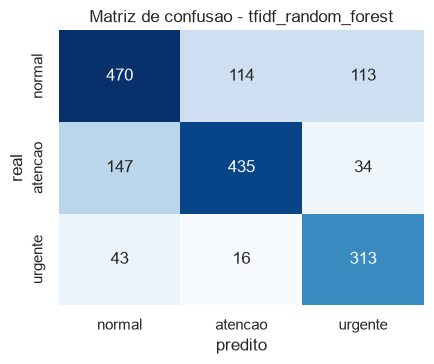

'urgente' classificado como 'normal': 43 de 372


In [7]:
matriz = confusion(teste["urgencia"], resultado["test_pred"])
fig, ax = plt.subplots(figsize=(4.5, 3.8))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title(f"Matriz de confusao - {CANDIDATO}")
plt.tight_layout()
plt.show()

erro_critico = matriz.loc["urgente", "normal"]
total_urgente = matriz.loc["urgente"].sum()
print(f"'urgente' classificado como 'normal': {erro_critico} de {total_urgente}")

> `urgente` predito como `normal` e o erro clinicamente caro. Um modelo com F1-macro alto e essa celula alta nao serve.

## 4. Latencia

In [8]:
latencia = pd.Series(resultado["latency"]).round(3).to_frame("ms")
display(latencia)

teto = CONFIG["promotion"]["max_latency_p95_ms"]
p95 = resultado["latency"]["latency_p95_ms"]
print(f"p95={p95:.2f}ms | teto={teto}ms | {'DENTRO' if p95 <= teto else 'ACIMA'}")

,ms
latency_p50_ms,150.608
latency_p95_ms,210.634
latency_p99_ms,244.626
latency_mean_ms,157.052
latency_n_calls,287.000


p95=210.63ms | teto=15.0ms | ACIMA


---

## Notas

_Ponto de atencao: se o p95 estourar o teto de latencia, o modelo e excluido da promocao mesmo com F1-macro competitivo. Isso e resultado a defender no video, nao problema a esconder - o enunciado diz 'Random Forest **ou modelo leve similar**'._